# Pretraitement
Redimensionnement, HSV/grayscale, filtrage, histogrammes.

## Description du pretraitement
Ce pretraitement uniformise la taille des images, reduit le bruit et rend les distributions de couleurs comparables.
- Redimensionnement: standardiser l entree pour ML/DL.
- RGB -> HSV et grayscale: separer information couleur et texture.
- Filtrage (Gaussian/Median): reduire le bruit tout en preservant les contours.
Les figures ci dessous montrent l impact visuel des transformations et les histogrammes confirment la redistribution des intensites.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "../data/dataset_tomato/Tomato_healthy/0a31e630-0d98-416b-b0e4-88a88aad1dc5___RS_HL 9653.JPG"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [8]:
img_resize = cv2.resize(img_rgb, (224, 224))
img_hsv = cv2.cvtColor(img_resize, cv2.COLOR_RGB2HSV)
img_gray = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)
img_gauss = cv2.GaussianBlur(img_resize, (5,5), 0)
img_median = cv2.medianBlur(img_resize, 5)

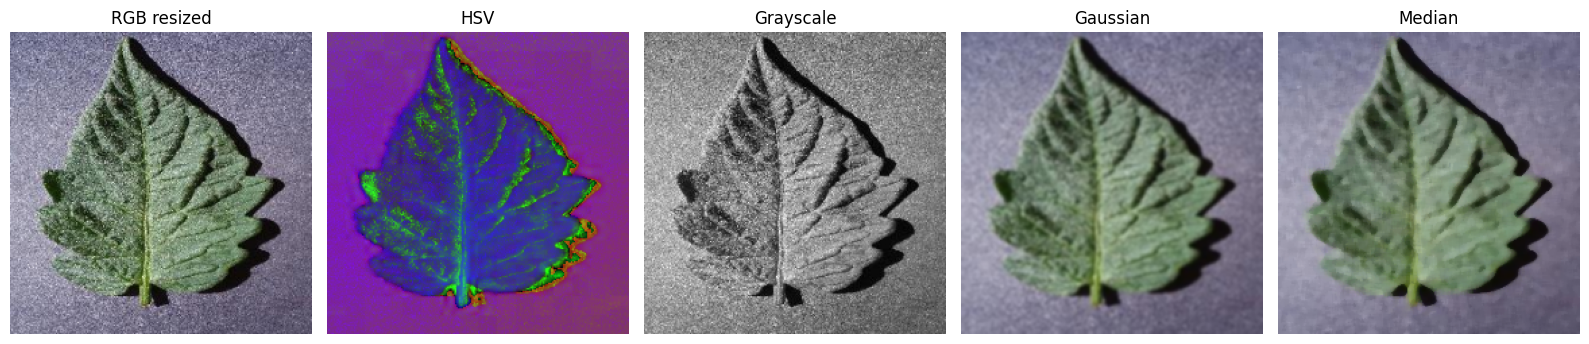

In [9]:
fig, ax = plt.subplots(1,5, figsize=(16,4))
ax[0].imshow(img_resize); ax[0].set_title("RGB resized")
ax[1].imshow(img_hsv); ax[1].set_title("HSV")
ax[2].imshow(img_gray, cmap="gray"); ax[2].set_title("Grayscale")
ax[3].imshow(img_gauss); ax[3].set_title("Gaussian")
ax[4].imshow(img_median); ax[4].set_title("Median")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

## Analyse de chaque fonction
- `cv2.resize`: uniformise la taille pour que les features et le DL travaillent sur des entrées comparables.
- `cv2.cvtColor(..., RGB2HSV)`: separe luminance et chrominance, utile pour isoler les feuilles vertes.
- `cv2.cvtColor(..., RGB2GRAY)`: concentre l information de texture, utile pour GLCM et contours.
- `cv2.GaussianBlur`: reduit le bruit fin tout en gardant la structure globale.
- `cv2.medianBlur`: filtre mieux les pixels aberrants (bruit impulsionnel), parfois plus propre que Gaussian.
- `cv2.calcHist`: permet de verifier la distribution des intensites/couleurs avant et apres pretraitement.

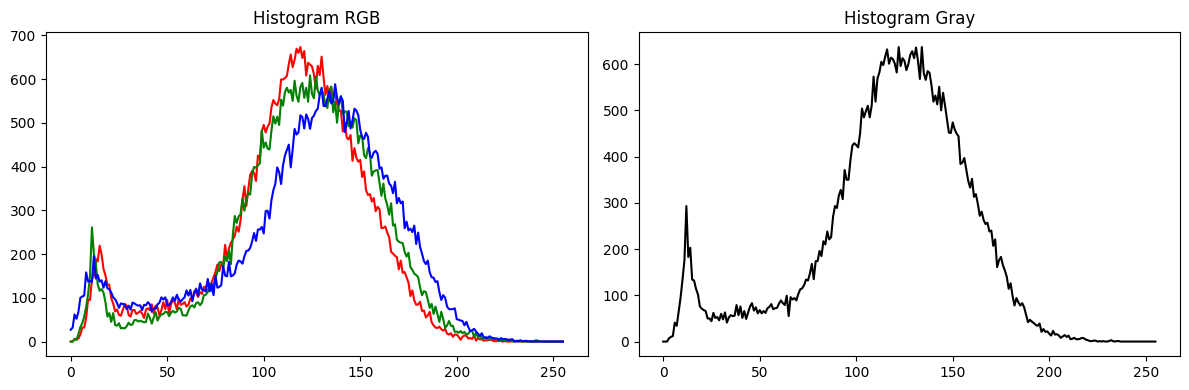

In [10]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title("Histogram RGB")
for i, col in enumerate(["r","g","b"]):
    hist = cv2.calcHist([img_resize], [i], None, [256], [0,256])
    plt.plot(hist, color=col)

plt.subplot(1,2,2)
plt.title("Histogram Gray")
hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0,256])
plt.plot(hist_gray, color="black")
plt.tight_layout()
plt.show()

## Analyse des histogrammes
- RGB: un pic tres fort indique une couleur dominante (souvent le vert de la feuille).
- Gray: une distribution serree indique peu de contraste; une distribution etalee indique plus de details et texture.
- Apres filtrage, les histogrammes deviennent plus lisses, signe d une reduction du bruit.
- Si les histogrammes sont tres differents entre images, cela peut indiquer des variations d eclairage a corriger.

In [ ]:
# src/preprocessing.py
import cv2, numpy as np

IMG_SIZE = (224, 224)

def preprocess_image(img_path: str, visualize=False) -> dict:
    """Pipeline complet de prétraitement avec visualisation optionnelle."""
    
    # 1. Lecture
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Redimensionnement
    img_resized = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)

    # 3. Conversion RGB → HSV (utile pour masquer le fond vert)
    img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)

    # 4. Conversion en grayscale
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

    # 5. Dénoise : Gaussien (flou doux) vs Médian (préserve les bords)
    img_gaussian = cv2.GaussianBlur(img_gray, (5,5), 0)
    img_median   = cv2.medianBlur(img_gray, 5)

    # 6. CLAHE : amélioration adaptative du contraste
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_gray)

    # 7. Normalisation [0,1]
    img_norm = img_resized.astype(np.float32) / 255.0

    if visualize:
        _show_preprocessing_steps(img_resized, img_hsv, img_gray,
                                   img_gaussian, img_median, img_clahe)

    return {
        "rgb":      img_resized,
        "hsv":      img_hsv,
        "gray":     img_gray,
        "gaussian": img_gaussian,
        "median":   img_median,
        "clahe":    img_clahe,
        "norm":     img_norm,
    }

def _show_preprocessing_steps(rgb, hsv, gray, gauss, median, clahe):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes[0,0].imshow(rgb);          axes[0,0].set_title("Original RGB")
    axes[0,1].imshow(hsv);          axes[0,1].set_title("HSV")
    axes[0,2].imshow(gray, cmap='gray'); axes[0,2].set_title("Grayscale")
    axes[1,0].imshow(gauss, cmap='gray'); axes[1,0].set_title("Gaussian blur")
    axes[1,1].imshow(median, cmap='gray'); axes[1,1].set_title("Median blur")
    axes[1,2].imshow(clahe, cmap='gray'); axes[1,2].set_title("CLAHE")
    for ax in axes.flat: ax.axis('off')
    plt.suptitle("Étapes de prétraitement", fontweight='bold')
    plt.tight_layout()
    plt.savefig("results/preprocessing_steps.png", dpi=150)
    plt.show()

def compute_histogram(img_rgb, title=""):
    """Analyse histogramme par canal R, G, B."""
    import matplotlib.pyplot as plt
    colors = ['red', 'green', 'blue']
    fig, ax = plt.subplots(figsize=(8,4))
    for i, c in enumerate(colors):
        hist = cv2.calcHist([img_rgb],[i],None,[256],[0,256])
        ax.plot(hist, color=c, alpha=0.7, label=c.upper())
    ax.set_xlabel("Intensité pixel"); ax.set_ylabel("Fréquence")
    ax.legend(); ax.set_title(f"Histogramme {title}")
    plt.tight_layout()
    plt.savefig(f"results/histogram_{title}.png", dpi=150)
    plt.show()